## Project Title: Telco Customer Churn 

### Project Summary:

#### About the Dataset

Telco customer churn: 
This dataset tracks a fictional telco company's customer churn based on a variety of possible factors. The churn column indicates whether or not the customer left within the last month. Other columns include gender, dependents, monthly charges, and many with information about the types of services each customer has. 

**Data Source:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Project Aim
To Build a machine learning classification pipeline that predicts customer churn from the Telco Customer Churn dataset. Your final solution must show evidence of proper data cleaning, thoughtful feature engineering, model training, model evaluation, and business interpretation.

---
### Import Required Libraries & Dataset

In [1]:
# install requirements
%pip install -r "../requirements.txt"


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
root = Path('..')
data_path = root/'data'
df = pd.read_csv(data_path/"WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
### Data Validation and Pre-Processing

In [3]:
display(df.shape)
display(df.columns)

(7043, 21)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
duplicates = df[df.duplicated()]
duplicates

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


> The dataset has no duplicates, No null values and the column names are in order

In [6]:
# Validate the Features Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

From the above results many of the columns have the been saved with the wrong datatype.
There are only 3 numerical columns which are `'tenure', 'MonthlyCharges'` and `'TotalCharges'`
therefore we shall now convert the remaining columns to categorical datatypes

In [8]:
# Identify the numerical & categorical columns
num_cols = df[['TotalCharges', 'MonthlyCharges', 'tenure']]
cat_cols = [col for col in df.columns if col not in num_cols and col != 'customerID']


In [9]:
# Convert all identified categorical columns to the category dtype
df[cat_cols] = df[cat_cols].astype('category')
df[cat_cols].describe(include=['category'])

# Convert TotalCharges to float, turning bad strings into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
# Re-confirm data validity
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
null= df[df['TotalCharges'].isna()]
null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
zero_tenure = df[df['tenure']==0]
zero_tenure

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Looking at these Customers with null values under `'TotalCharges'` it can be observed that they are also the only customers with `'tenure'` = 0 too.   
Its safe to assume that this customers have no records for `'TotalCharges'` because there are new to the product therefore we shall fill them with `0's`

In [13]:
df.fillna(0, inplace = True)
df.isna().sum().sum()

np.int64(0)

---
### Exploratory Data Analysis

#### Understanding the Target

In [14]:
data= df.copy()

In [15]:
display(data['Churn'].value_counts())
display(data['Churn'].unique())

Churn
No     5174
Yes    1869
Name: count, dtype: int64

['No', 'Yes']
Categories (2, str): ['No', 'Yes']

In [16]:
churn_pct = (
    data['Churn'].value_counts(normalize=True))
churn_pct

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [17]:
# Lets map the 'No'/'Yes' text strings to standard binary numbers
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

print(data['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: category
Categories (2, int64): [0, 1]


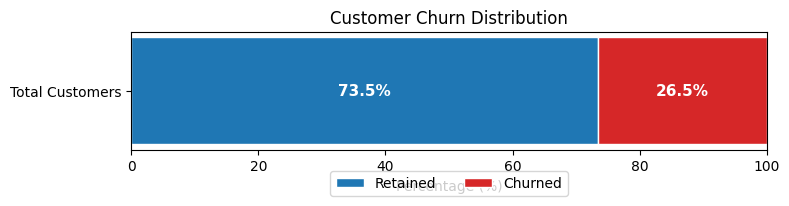

In [18]:
# Calculate churn percentages (0 = Retained, 1 = Churned)
churn_pct = (
    data['Churn']
    .value_counts(normalize=True)
    .reindex([0, 1], fill_value=0)
    .mul(100)
)

# Plot
fig, ax = plt.subplots(figsize=(8, 2.5))

start = 0
colors = ['#1f77b4', '#d62728']
labels = ['Retained', 'Churned']

for value, color, label in zip(churn_pct.values, colors, labels):

    # Draw each section of the stacked bar
    ax.barh(
        y='Total Customers',
        width=value,
        left=start,
        color=color,
        edgecolor='white',
        label=label
    )

    # Percentage label
    if value > 0:
        ax.text(
            x=start + value / 2,
            y=0,
            s=f'{value:.1f}%',
            ha='center',
            va='center',
            color='white',
            fontsize=11,
            fontweight='bold'
        )

    start += value

# Formatting
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')
ax.set_title('Customer Churn Distribution')

ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.45),
    ncol=2,
    frameon=True
)

# Remove unnecessary y-axis label
ax.set_ylabel('')

plt.tight_layout()
plt.show()

Our target variable is slightly imbalanced with the number of churned customers constituting only about 27% of the available record.

#### Categorical columns versus churn

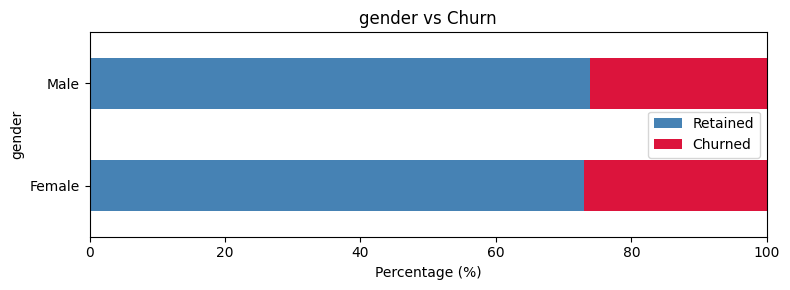

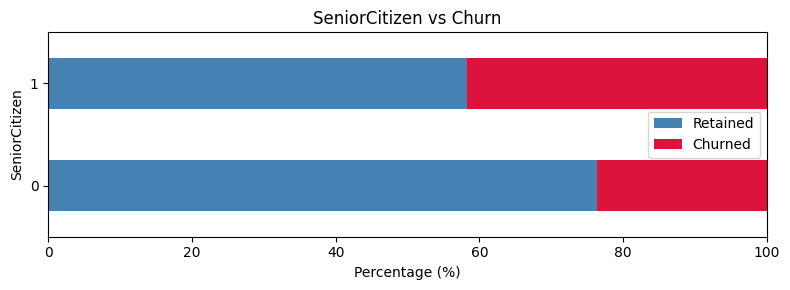

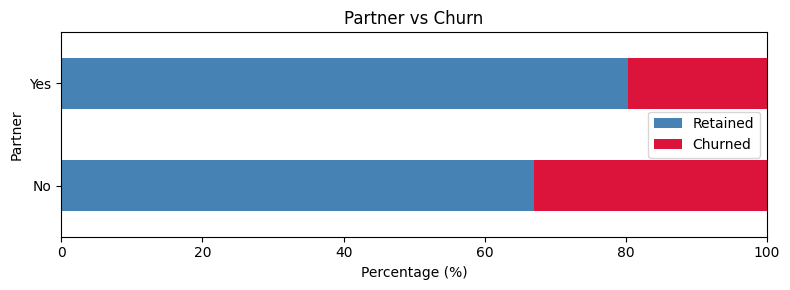

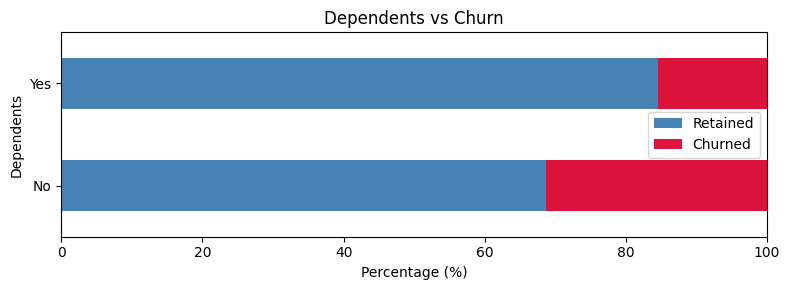

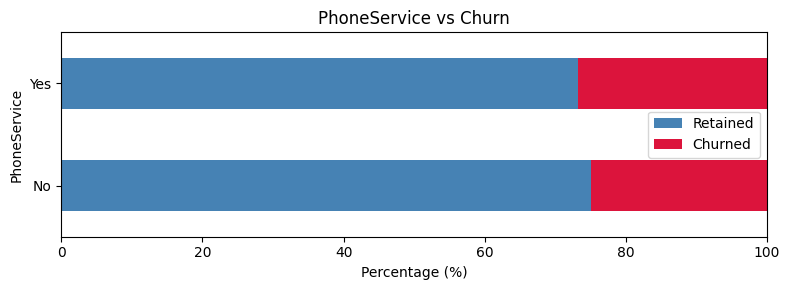

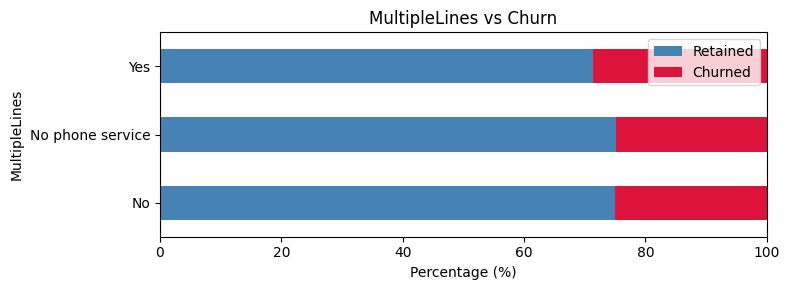

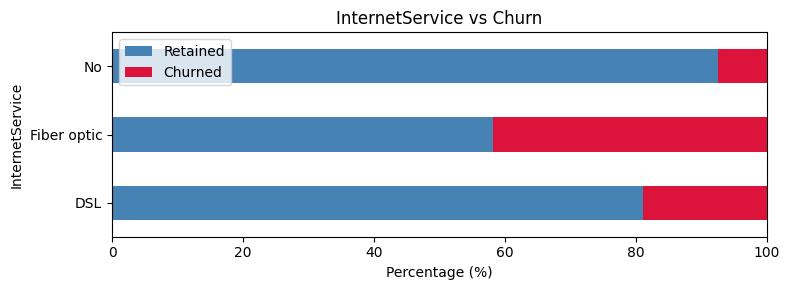

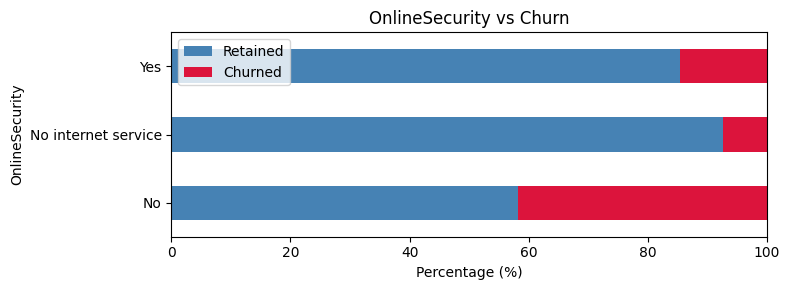

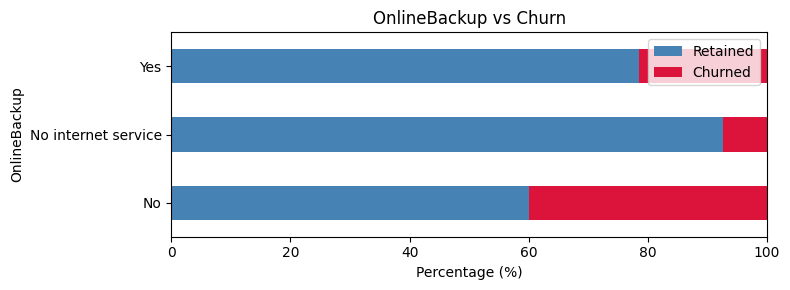

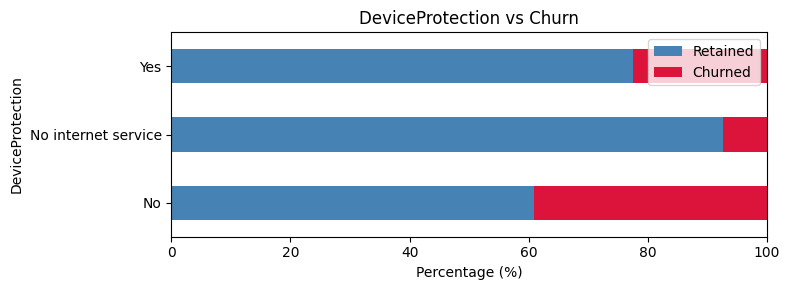

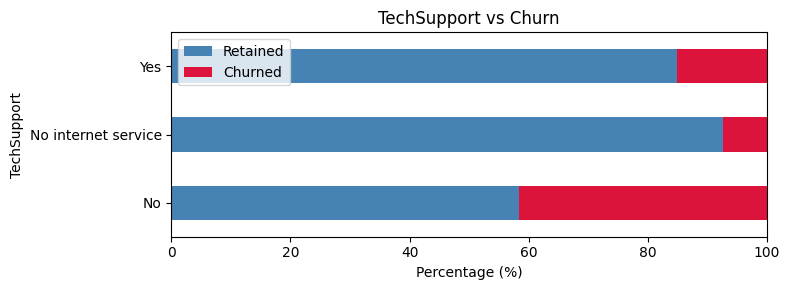

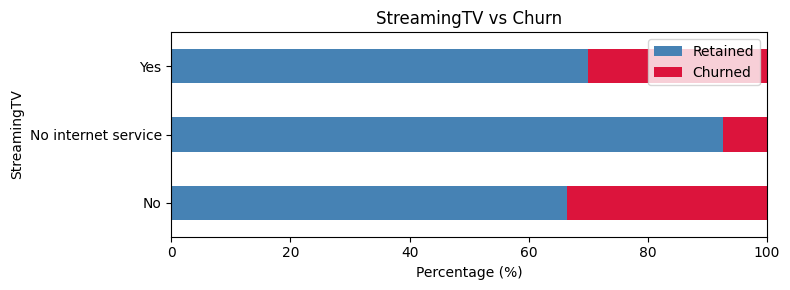

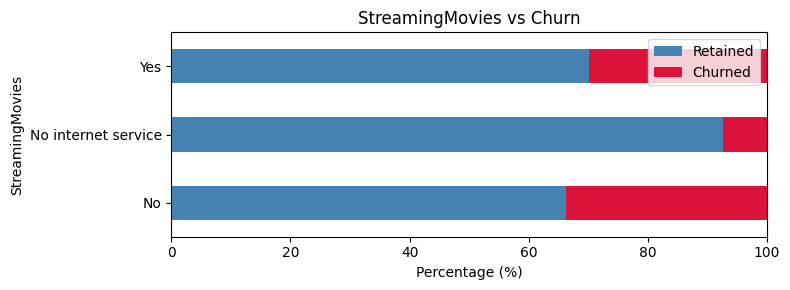

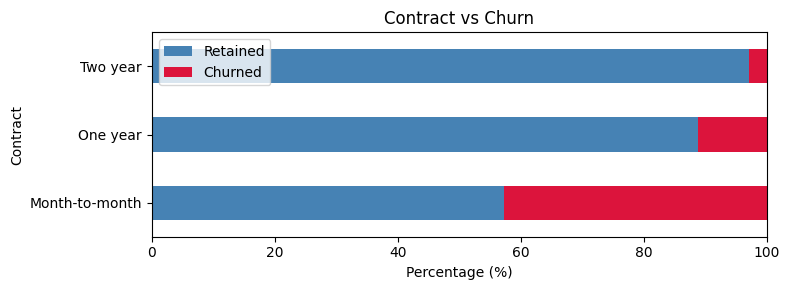

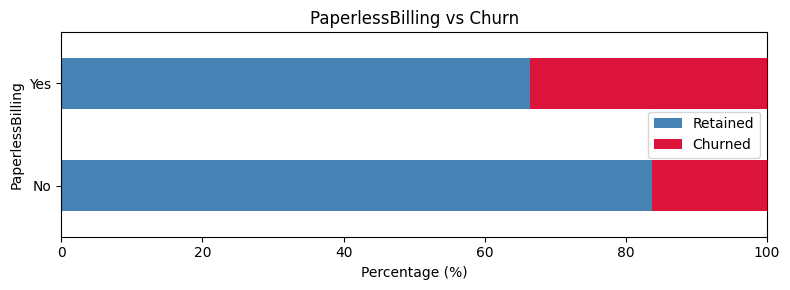

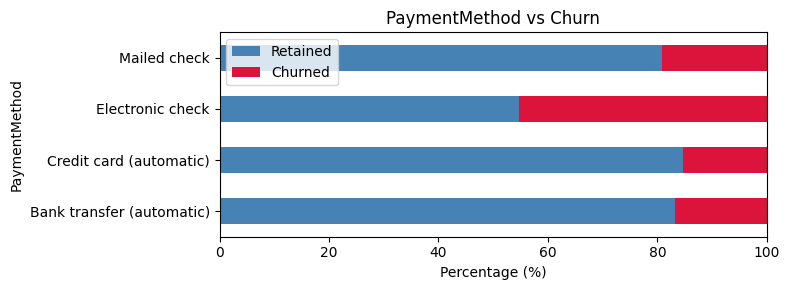

In [19]:
for col in cat_cols:
    if col != 'Churn':

        table = (pd.crosstab(data[col], data['Churn'],
            normalize='index') * 100)

        table.plot(
            kind='barh',
            stacked=True,
            figsize=(8, max(3, len(table) * 0.5)),
            color=['steelblue', 'crimson']
        )

        plt.title(f'{col} vs Churn')
        plt.xlabel('Percentage (%)')
        plt.ylabel(col)
        plt.xlim(0, 100)
        plt.legend(['Retained', 'Churned'])
        plt.tight_layout()
        plt.show()

Certain categorical features like `'dependents' and 'partner'`, `'StreamingTV' and 'StreamingMovies'` exhibit similar curn distributions indicating a possible liklihood of multicolinearity.

#### Numerical columns versus churn

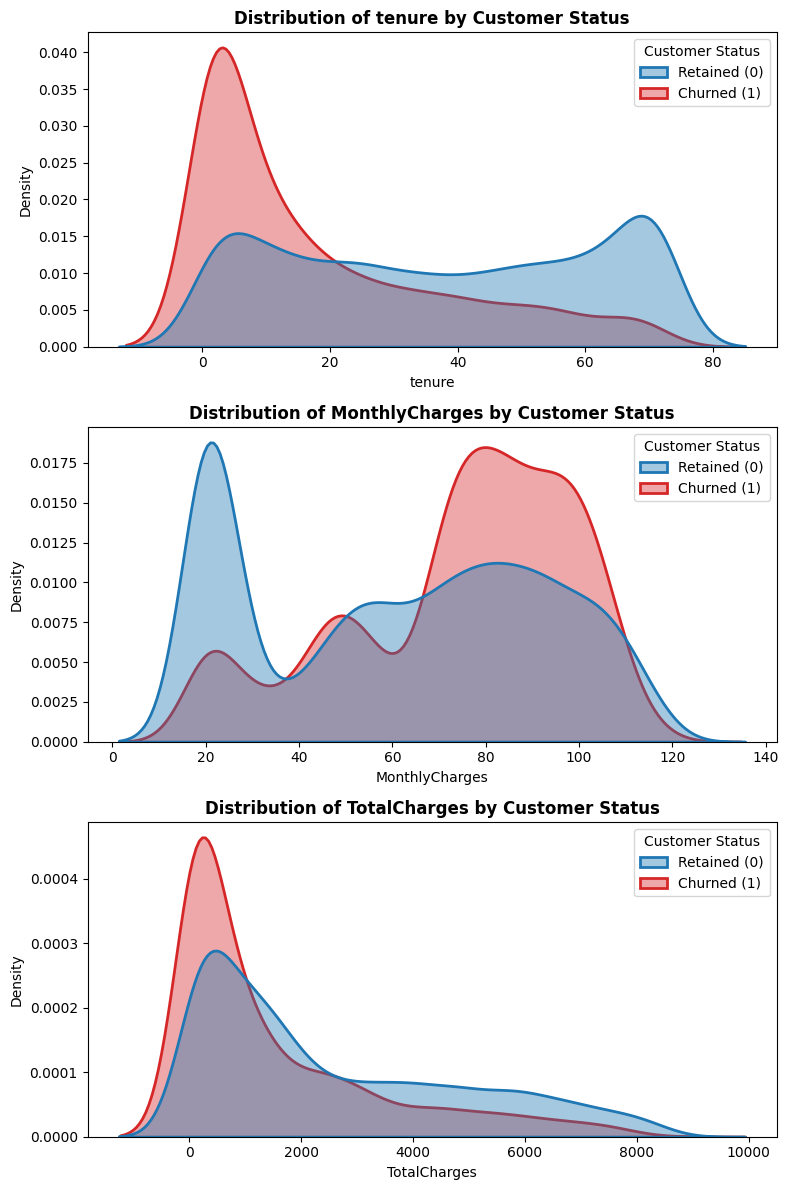

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Automatically find all numerical columns (excluding your Churn target)
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

# 2. Set up the plotting grid (1 row per numerical feature)
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(8, 4 * len(num_cols)))

# Handle case where there's only 1 numeric column
if len(num_cols) == 1:
    axes = [axes]

# 3. Loop through and create a distribution plot for each feature
for ax, col in zip(axes, num_cols):
    sns.kdeplot(
        data=data, 
        x=col, 
        hue='Churn', 
        fill=True, 
        common_norm=False,  # Normalizes each curve independently
        palette=['#1f77b4', '#d62728'],  # Blue for Retained, Red for Churned
        alpha=0.4, 
        linewidth=2,
        ax=ax
    )
    
    # Formatting each subplot
    ax.set_title(f'Distribution of {col} by Customer Status', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    
    # Clean up the legend labels dynamically
    legend = ax.get_legend()
    if legend:
        legend.set_title("Customer Status")
        for text, label in zip(legend.get_texts(), ['Retained (0)', 'Churned (1)']):
            text.set_text(label)

plt.tight_layout()
plt.show()


The above KDE (Kernel Density Estimate) plot allows us to compare the distribution of the two groups (Blue/ Retained) versus (Red/ Churned). Wherever the red curve climbs higher than the blue curve, it signals a high-risk zone for churn.    

Churn Vs Tenure
A good portion of your churned customers leave within their first few months of signing up. This is your highest-risk zone. the blue hill rising on the right side, peaking around 70 months. This indicates that if a customer survives past the first 20 months, they become highly loyal and are very likely to remain retained long-term.    

Business Insight: Your onboarding process or early-stage product experience needs urgent attention. Customers are dropping out rapidly right after signing up.


Churn Vs MonthlyCharges
There is a massive blue peak around $20 shows a large, stable group of retained customers who pay very low monthly fees. The massive red area between $70 and $100 reveals that customers with high monthly bills make up the vast majority of churn pool.   

Business Insight: Price sensitivity is a major driver of churn. Customers on expensive plans are actively abandoning the service, likely because they feel they aren't getting enough value for their money, or competitors are offering cheaper rates.


Churn Vs TotalCharges
The massive, sharp red peak concentrated near $0 to $1000 proves that most customers who leave do so before they accumulate any meaningful lifetime spending. The blue curve stays higher than the red curve across every value past $2,000. Long-term loyal accounts dominate the higher ranges of total expenditure, generating the bulk of the company's historical revenue.

---
### Feature Engineering

#### Check for Multi-Colinearity


For this we shall be using the Cramér's V Correlation Matrix Heatmap. It is the categorical equivalent of a correlation coefficient. It measures how strongly two categorical variables are associated.

0 = No association   
1 = Perfect association

In [21]:
eda_data = data.copy()

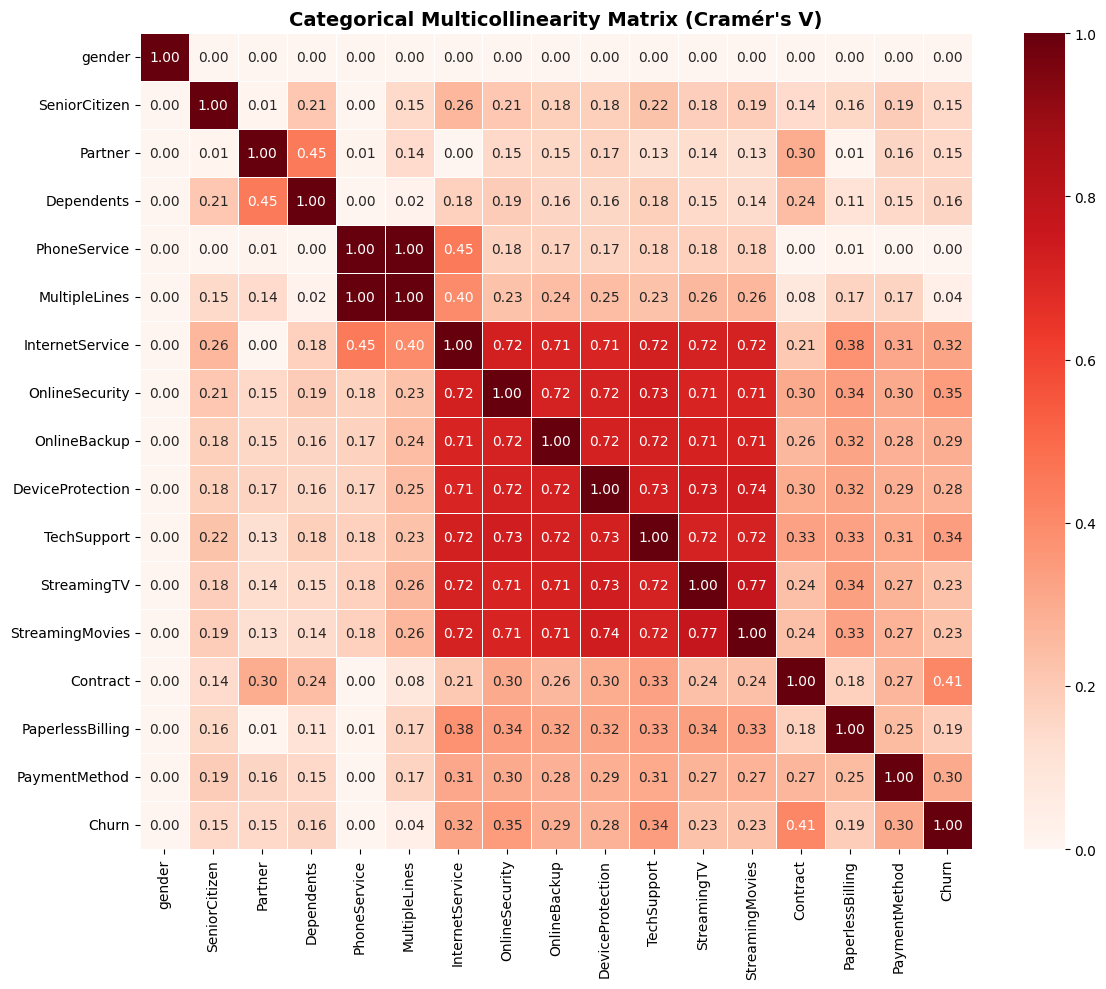

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Define a helper function to calculate Cramér's V between two columns
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Apply Bias Correction for more accurate smaller-sample limits
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Build an empty matrix matching the length of your categorical list
n_features = len(cat_cols)
v_matrix = np.zeros((n_features, n_features))

# 3. Fill the matrix by computing Cramér's V for every unique feature pair
for i in range(n_features):
    for j in range(n_features):
        v_matrix[i, j] = cramers_v(eda_data[cat_cols[i]], eda_data[cat_cols[j]])

# Convert the NumPy matrix into a beautifully indexed Pandas DataFrame
cramers_v_df = pd.DataFrame(v_matrix, index=cat_cols, columns=cat_cols)

# 4. Plot the results as a scannable Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cramers_v_df, 
    annot=True, 
    fmt=".2f", 
    cmap="Reds", 
    vmin=0, vmax=1,
    linewidths=0.5
)
plt.title("Categorical Multicollinearity Matrix (Cramér's V)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 Cramér's V heatmap provides an excellent blueprint of the data's structural relationships. It flags clear, severe multicollinearity issues that you should fix before moving on to model training.


From the above heatmap there are several clusters with multicollinearity scores of over 0.70
This is understandable because InternetService shares a massive relationship (0.71 to 0.72) with all the add-on internet features: OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport. Any customer who has "No Internet Service" will automatically have "No" across all five columns including StreamingTV and StreamingMovies.


There's a perfect correlation score of "1.00" between PhoneService and MultipleLines.
 If a customer does not have PhoneService, they structurally cannot have MultipleLines making both features identical, Since having both features are redundant we must drop one "MultipleLines".


**Note: Linear Models are not robust to Multicolinearity**




In [23]:
# Perfect 1.00 duplication with PhoneService
columns_to_drop = ['MultipleLines']

eda_data = eda_data.drop(columns=columns_to_drop)

In [24]:
eda_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

#### Feature Encoding

In [25]:
# Seperate our Target variable from the Predictor variables

y = eda_data['Churn']
X = eda_data.drop(columns =[ 'customerID', 'Churn'])

# Re initialize the categorical columns
new_cat_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()

In [26]:
# Encode the Predictor variables

X_encoded = pd.get_dummies(X, columns=new_cat_cols, drop_first=True, dtype=int)
X_encoded.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,0,0,0,0,1,1,0,...,0,0,0,0,0,0,1,0,1,0


---
### Model Selection, Training and Evaluation

In [27]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, 
                                   random_state= 42, stratify =y)



In [28]:
# Scale the features (Required for linear models like Logistic Regression, KNN, and SVM)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Training

For this project we shall train the six most popular classification models
 > `"Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine", "Random Forest Classifier", "XGBoost", "LightGBM"`

While training we would ensure we only apply the scaled version of `X-train` and `X-test` to the linear models.   
We will also set the hyperparameters `class_weight or pos_weight` of the tree based  models to makeup for the imbalanced dataset.
Models whose hyperparameters were set to accomodate the class imbalance are tagged **'Balanced'**.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# Calculate class imbalance ratio for balanced ensemble models

scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Define models
# Models requiring scaling are wrapped inside a Pipeline.
# Tree-based models remain unchanged.

classifiers = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier",
            KNeighborsClassifier(
                n_neighbors=5
            ))
    ]),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier",
            SVC(
                probability=True,
                random_state=42
            ))
    ]),

    "Random Forest (Balanced)":
        RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42
        ),

    "XGBoost (Balanced)":
        xgb.XGBClassifier(
            scale_pos_weight=scale_pos_weight_value,
            random_state=42,
            eval_metric="logloss"
        ),

    "LightGBM (Balanced)":
        lgb.LGBMClassifier(
            scale_pos_weight=scale_pos_weight_value,
            random_state=42,
            verbose=-1
        )
}

# Train and evaluate models

compiled_metrics = []

print("--- Comprehensive Model Evaluation ---")

for name, model in classifiers.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Predicted probabilities (required for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    compiled_metrics.append({
        "Model Name": name,
        "Accuracy": f"{accuracy:.2%}",
        "Precision": f"{precision:.2%}",
        "Recall": f"{recall:.2%}",
        "F1-Score": f"{f1:.2%}",
        "ROC-AUC": f"{roc_auc:.2%}",
        "True Neg (Retained)": tn,
        "False Pos (False Alarm)": fp,
        "False Neg (Missed Churn)": fn,
        "True Pos (Caught Churn)": tp
    })

# Results Table

performance_df = (
    pd.DataFrame(compiled_metrics)
      .set_index("Model Name")
)

performance_df

--- Comprehensive Model Evaluation ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,True Neg (Retained),False Pos (False Alarm),False Neg (Missed Churn),True Pos (Caught Churn)
Model Name,,,,,,,,,
Logistic Regression,80.84%,66.25%,56.68%,61.10%,84.29%,927,108,162,212
K-Nearest Neighbors,75.02%,53.18%,49.20%,51.11%,76.86%,873,162,190,184
Support Vector Machine,79.06%,63.57%,49.47%,55.64%,79.79%,929,106,189,185
Random Forest (Balanced),78.07%,61.48%,46.52%,52.97%,82.20%,926,109,200,174
XGBoost (Balanced),75.80%,53.47%,67.91%,59.84%,81.79%,814,221,120,254
LightGBM (Balanced),75.44%,52.62%,75.13%,61.89%,83.62%,782,253,93,281


In [30]:
from sklearn.metrics import classification_report

# Check performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409



### Initial Model Performance Report and Interpretation

The table above compares the performance of the six machine learning classifiers . Because the dataset exhibits a class imbalance of approximately **74% non-churners to 26% churners**, overall accuracy alone provides a misleading assessment of model performance. Therefore, we shall rely on **Precision**, **Recall**, and **F1-Score**, as the primary evaluation metric of the models with the F1-Score serving as the principal metric because it balances the trade-off between correctly identifying churners -Recall- and minimizing false alarms -precision-.

#### 1. LightGBM (Balanced)

The LightGBM model achieved the best overall performance, recording the highest **F1-Score (61.89%)** and **Recall (75.13%)**. It correctly identified **281 of 374 churners**, making it the most effective model for maximizing customer retention. However, this higher recall came at the cost of **253 false positives**, resulting in more unnecessary retention interventions.


#### 2. Logistic Regression

Logistic Regression achieved an **F1-Score of 61.10%** while recording the **highest Precision (66.25%)** and overall accuracy. It generated only **108 false positives**, making it well suited for cost-sensitive retention campaigns. However, its lower recall resulted in **162 missed churners**, reflecting a more conservative prediction strategy that prioritizes precision over capturing every potential churner.


#### 3. Performance of the Remaining Models

**XGBoost (Balanced)**

XGBoost demonstrated performance comparable to LightGBM but consistently achieved slightly lower Precision, Recall, and F1-Score. While it effectively identified churners, it did not provide sufficient improvement over LightGBM to justify selection as the preferred model.

 **Random Forest and Support Vector Machine (SVM)**

Both Random Forest and SVM exhibited comparatively weaker performance in identifying churners, reflected by their lower Recall and F1-Scores. Their results suggest that these models were less effective at distinguishing minority-class observations within this dataset.

 **K-Nearest Neighbors (KNN)**

KNN produced the weakest overall performance. This outcome is consistent with the algorithm's sensitivity to high-dimensional feature spaces. After one-hot encoding, the large number of binary variables reduces the effectiveness of distance-based similarity measures, making accurate neighbour identification more challenging.


#### Note: F1-Score versus AUC

The **F1-Score** evaluates model performance at a specific classification threshold (typically **0.50**) by balancing Precision and Recall. Consequently, a model with a relatively modest F1-Score may still perform well if an alternative decision threshold is selected.

In contrast, the **Area Under the ROC Curve (AUC-ROC)** measures the model's ability to distinguish between churners and non-churners **across all possible classification thresholds**. A higher AUC indicates stronger overall discriminative ability, regardless of the threshold ultimately chosen for deployment.

For this reason, F1-Score is useful for comparing models under the current operating threshold, whereas AUC provides a broader assessment of each model's underlying classification capability.


---
### Cross Validation


Lets Re-train the model while performing Stratified 5-Fold Cross-Validation to rigorously evaluate the models on the training data.

In [65]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("Running 5-Fold Cross Validation...\n")

for name, model in classifiers.items():
    scores = cross_validate(estimator=model,
        X=X_train, y=y_train, cv=cv,
        scoring={
            "Accuracy": "accuracy",
            "Precision": "precision",
            "Recall": "recall",
            "F1": "f1",
            "ROC_AUC": "roc_auc"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_Accuracy"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "Recall": scores["test_Recall"].mean(),
        "F1-Score": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC_AUC"].mean()
    })

cv_df = (
    pd.DataFrame(cv_results)
      .set_index("Model")
      .sort_values("F1-Score", ascending=False)
)

cv_df.style.format("{:.2%}")

Running 5-Fold Cross Validation...



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
LightGBM (Balanced),76.96%,54.86%,74.18%,63.06%,83.71%
XGBoost (Balanced),76.73%,55.14%,66.09%,60.11%,82.23%
Logistic Regression,80.16%,65.18%,54.25%,59.14%,84.57%
Support Vector Machine,80.25%,66.81%,50.84%,57.71%,80.14%
Random Forest (Balanced),78.93%,63.85%,47.69%,54.59%,82.58%
K-Nearest Neighbors,76.20%,55.57%,51.44%,53.40%,77.58%


--- 
### Hyper-Parameter Tuning

For Compute reasons we shall not be tuning the SVM and KNN models

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [72]:
from sklearn.model_selection import RandomizedSearchCV

# Logistic Regression Hyperparameter Tuning
log_params = {
    "classifier__C": [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100],
    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ],
    "classifier__penalty": [
        "l2"
    ]
}

log_search = RandomizedSearchCV(
    estimator=classifiers["Logistic Regression"],
    param_distributions=log_params,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

log_search.fit(X_train, y_train)

best_log = log_search.best_estimator_

print("\nBest Logistic Regression Parameters:")
print(log_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(f"{log_search.best_score_:.4f}")


# Random Forest Hyperparameter Tuning
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=classifiers["Random Forest (Balanced)"],
    param_distributions=rf_params,
    n_iter=50,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(f"{rf_search.best_score_:.4f}")


# LightGBM Hyperparameter Tuning

lgb_params = {
    "n_estimators": [100, 500, 1000, 1500],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [20, 31, 50, 70],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

lgb_search = RandomizedSearchCV(
    estimator=classifiers["LightGBM (Balanced)"],
    param_distributions=lgb_params,
    n_iter=50,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgb_search.fit(X_train, y_train)

best_lgb = lgb_search.best_estimator_

print("\nBest LightGBM Parameters:")
print(lgb_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(f"{lgb_search.best_score_:.4f}")


# XGBoost Hyperparameter Tunin
xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=classifiers["XGBoost (Balanced)"],
    param_distributions=xgb_params,
    n_iter=50,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\nBest XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(f"{xgb_search.best_score_:.4f}")




# K-Nearest Neighbors Hyperparameter Tuning
knn_params = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15, 20, 25, 30],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan", "minkowski"],
    "classifier__p": [1, 2]
}

knn_search = RandomizedSearchCV(
    estimator=classifiers["K-Nearest Neighbors"],
    param_distributions=knn_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

knn_search.fit(X_train, y_train)

best_knn = knn_search.best_estimator_

print("\nBest KNN Parameters:")
print(knn_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(f"{knn_search.best_score_:.4f}")


# Summary of All Tuned Models
tuning_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression (Tuned)",
        "Random Forest (Tuned)",
        "LightGBM (Tuned)",
        "XGBoost (Tuned)",
        "KNN (Tuned)"
    ],

    "Best CV F1": [
        log_search.best_score_,
        rf_search.best_score_,
        lgb_search.best_score_,
        xgb_search.best_score_,
        knn_search.best_score_
    ],

    "Best Parameters": [
        log_search.best_params_,
        rf_search.best_params_,
        lgb_search.best_params_,
        xgb_search.best_params_,
        knn_search.best_params_
    ]
}).set_index("Model")

tuning_summary

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\USER\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Best Logistic Regression Parameters:
{'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 0.5}

Best Cross-Validated F1-Score:
0.5925
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Random Forest Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

Best Cross-Validated F1-Score:
0.6347
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best LightGBM Parameters:
{'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best Cross-Validated F1-Score:
0.6320
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best Cross-Validated F1-Score:
0.6385
Fitting 5 folds for each of 30 candidates, totall

,Best CV F1,Best Parameters
Model,,
Logistic Regression (Tuned),0.592480,"{'classifier__solver': 'liblinear', 'classifie..."
Random Forest (Tuned),0.634730,"{'n_estimators': 200, 'min_samples_split': 10,..."
LightGBM (Tuned),0.632022,"{'subsample': 1.0, 'num_leaves': 20, 'n_estima..."
XGBoost (Tuned),0.638504,"{'subsample': 1.0, 'n_estimators': 300, 'min_c..."
KNN (Tuned),0.603335,"{'classifier__weights': 'uniform', 'classifier..."


In [73]:
best_params = pd.DataFrame({
    "Logistic Regression": log_search.best_params_,
    "Random Forest": rf_search.best_params_,
    "LightGBM": lgb_search.best_params_,
    "XGBoost": xgb_search.best_params_,
    "K-Nearest Neighbors": knn_search.best_params_
}).T


best_params

,classifier__solver,classifier__penalty,classifier__C,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,subsample,num_leaves,min_child_samples,learning_rate,colsample_bytree,min_child_weight,gamma,classifier__weights,classifier__p,classifier__n_neighbors,classifier__metric
Logistic Regression,liblinear,l2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Random Forest,NaN,NaN,NaN,200,10,1,sqrt,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,NaN,NaN,NaN,100.0,NaN,NaN,NaN,-1.0,1.0,20.0,20.0,0.1,1.0,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,NaN,NaN,NaN,300.0,NaN,NaN,NaN,3.0,1.0,NaN,NaN,0.05,0.8,5.0,0.1,NaN,NaN,NaN,NaN
K-Nearest Neighbors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,uniform,1,25,manhattan


In [74]:

# Evaluate Tuned Models on the Test Set

tuned_models = {
    "Logistic Regression (Tuned)": best_log,
    "Random Forest (Tuned)": best_rf,
    "LightGBM (Tuned)": best_lgb,
    "XGBoost": best_xgb,
    "K-Nearest Neighbors": best_knn
}

tuned_results = []
print("--- Tuned Model Evaluation ---")

for name, model in tuned_models.items():

    # Fit the tuned model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    tuned_results.append({
        "Model Name": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "True Neg (Retained)": tn,
        "False Pos (False Alarm)": fp,
        "False Neg (Missed Churn)": fn,
        "True Pos (Caught Churn)": tp
    })

tuned_df = (
    pd.DataFrame(tuned_results)
      .set_index("Model Name")
)

tuned_df.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}",
    "ROC-AUC": "{:.2%}"
})

--- Tuned Model Evaluation ---


C:\Users\USER\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,True Neg (Retained),False Pos (False Alarm),False Neg (Missed Churn),True Pos (Caught Churn)
Model Name,,,,,,,,,
Logistic Regression (Tuned),80.77%,66.14%,56.42%,60.89%,84.25%,927,108,163,211
Random Forest (Tuned),76.79%,54.53%,75.67%,63.38%,84.27%,799,236,91,283
LightGBM (Tuned),75.66%,52.84%,77.01%,62.68%,83.86%,778,257,86,288
XGBoost,74.38%,51.12%,79.41%,62.20%,84.16%,751,284,77,297
K-Nearest Neighbors,77.71%,58.15%,57.22%,57.68%,82.44%,881,154,160,214




------------------------------
### Model Optimization



 To complement the threshold-dependent performance metrics, we now examine the **Receiver Operating Characteristic (ROC) curve** and the **Area Under the Curve (AUC)**. Unlike Precision, Recall, and the F1-Score, which are evaluated at a single classification threshold (typically 0.50), the ROC curve illustrates each model's performance across **all possible decision thresholds** ranging from 0 to 1.

Specifically, the ROC curve plots the **True Positive Rate (Recall)** against the **False Positive Rate**, providing a visual representation of each model's ability to distinguish between churners and non-churners. The corresponding **AUC score** summarizes this performance into a single value, where a higher AUC indicates stronger overall discriminative ability and a greater likelihood that the model will correctly rank a randomly selected churner above a randomly selected non-churner.


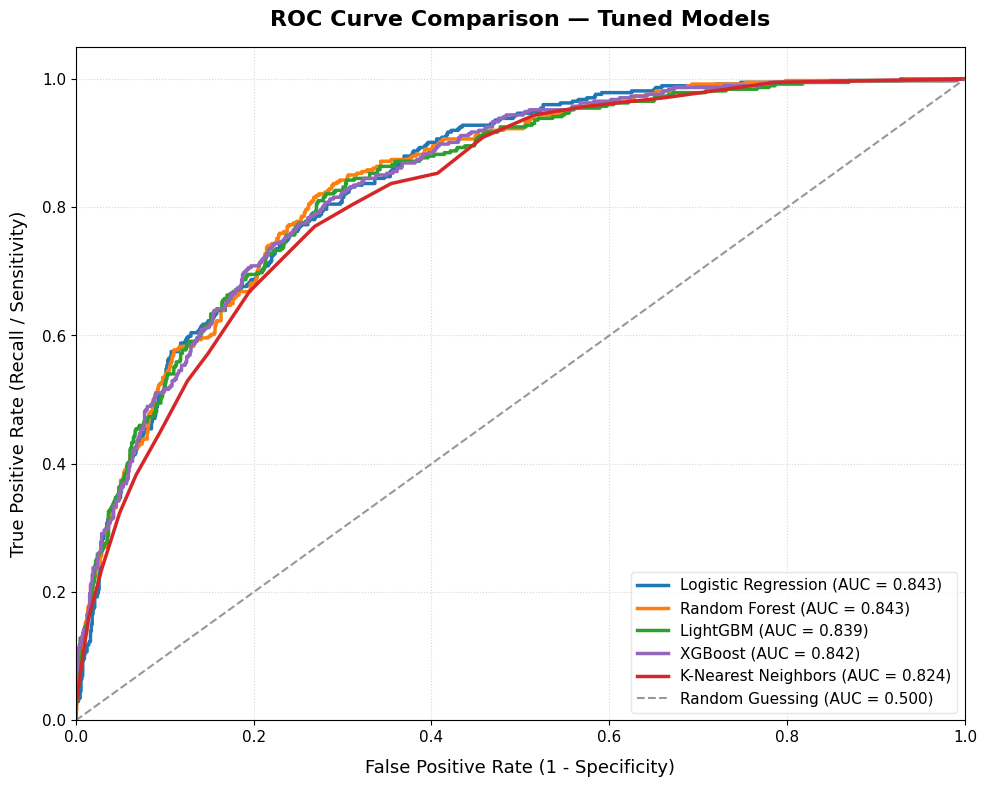

In [75]:
# ROC CURVE — TUNED MODELS (EXCLUDING SVM)
# Store the tuned models
tuned_models = {
    "Logistic Regression": best_log,
    "Random Forest": best_rf,
    "LightGBM": best_lgb,
    "XGBoost": best_xgb,
    "K-Nearest Neighbors": best_knn
}

# Configure plot appearance
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15

# Initialize figure
plt.figure(figsize=(10, 8))

# Colors for the five models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

# Plot ROC Curve for Each Tuned Model
for (name, model), color in zip(tuned_models.items(), colors):
    try:

        # All models are pipelines where necessary,
        # so X_test can be passed directly.
        y_prob = model.predict_proba(X_test)[:, 1]

        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)

        # Calculate ROC-AUC
        auc = roc_auc_score(y_test, y_prob )

        # Plot ROC curve
        plt.plot(fpr, tpr,
            label=f'{name} (AUC = {auc:.3f})',
            color=color, linewidth=2.5)

    except Exception as e:
        print(f"Skipping {name}: {e}")

# Random Guessing Reference Line
plt.plot([0, 1], [0, 1],
    linestyle='--', color='#7f7f7f',
    alpha=0.8, linewidth=1.5,
    label='Random Guessing (AUC = 0.500)')


# Plot Formatting
plt.title('ROC Curve Comparison — Tuned Models', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', labelpad=10)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', labelpad=10)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(loc='lower right',
    fontsize=11, frameon=True,
    facecolor='white', edgecolor='#e0e0e0')

plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### ROC-AUC Interpretation

The ROC curves indicate that all evaluated models demonstrate meaningful discriminatory power, as each achieves an AUC substantially greater than **0.50**, which represents random classification. However, differences in their AUC scores highlight variations in each model's ability to distinguish between churners and non-churners across all possible decision thresholds.

**Logistic Regression (AUC = 0.843)** and **LightGBM (AUC = 0.836)** achieved the highest AUC scores, indicating the strongest overall discriminative ability. These results suggest that both models consistently rank customers according to their likelihood of churning, regardless of the classification threshold. This supports the earlier findings that these two models are the strongest candidates for deployment.

**Random Forest (AUC = 0.822)** and **XGBoost (AUC = 0.818)** formed the second-best performing group. Although their threshold-dependent metrics (such as F1-Score and Recall) were slightly lower than those of the top-performing models, their relatively high AUC values indicate good underlying classification capability. This suggests that alternative decision thresholds or further hyperparameter optimization could potentially improve their operational performance.

**Support Vector Machine (AUC = 0.798)** and **K-Nearest Neighbours (AUC = 0.769)** recorded the lowest AUC scores among the evaluated models. While both models performed better than random guessing, they demonstrated comparatively weaker ability to distinguish between churners and non-churners on this dataset. Their lower AUC values are consistent with their weaker Precision, Recall, and F1-Scores observed in the initial model evaluation.

Overall, the ROC-AUC analysis reinforces the conclusions drawn from the threshold-based evaluation metrics. Logistic Regression and LightGBM exhibit the strongest overall classification capability, with LightGBM favouring higher recall and Logistic Regression offering greater precision. Consequently, these two models remain the most suitable candidates for customer churn prediction, with the final selection depending on the organization's retention objectives and the relative costs of false positives and false negatives.


---
### Threshold Optimization

Through threshold optimization we shall select the best probability cutoff or decision boundary that'll produced the highest F1-Score for the given models instead of using the default 0.5 value.



In [76]:
# Storage for optimized performance metrics
optimized_metrics = []

print("--- Executing Multi-Model Threshold Optimization Loop ---\n")

for name, model in tuned_models.items():

    try:
        # 1. Obtain probability of Churn = 1
        y_prob = model.predict_proba(X_test)[:, 1]

        # 2. Calculate ROC-AUC
        roc_auc = roc_auc_score(y_test, y_prob)

        # 3. Search for threshold that maximizes F1
        best_threshold = 0.50
        best_f1 = 0.0

        for thresh in np.linspace(0.01, 0.99, 100):

            y_pred_temp = (y_prob >= thresh).astype(int)

            current_f1 = f1_score(y_test,
                y_pred_temp, zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_threshold = thresh

        # 4. Generate predictions using optimal threshold
        y_pred_optimized = (
            y_prob >= best_threshold
        ).astype(int)

        # 5. Calculate optimized metrics
        accuracy = np.mean(y_pred_optimized == y_test)

        precision = precision_score(y_test,
            y_pred_optimized, zero_division=0)

        recall = recall_score(y_test,
            y_pred_optimized, zero_division=0)

        f1 = f1_score(y_test,
            y_pred_optimized, zero_division=0)

        tn, fp, fn, tp = confusion_matrix( y_test,
            y_pred_optimized).ravel()

        # 6. Store results
        optimized_metrics.append({
            "Model Name": name,
            "Best Threshold": round(best_threshold, 4),
            "ROC-AUC": f"{roc_auc:.3f}",
            "Accuracy": f"{accuracy:.2%}",
            "Precision": f"{precision:.2%}",
            "Recall": f"{recall:.2%}",
            "F1-Score": f"{f1:.2%}",
            "True Neg (Retained)": tn,
            "False Pos (False Alarm)": fp,
            "False Neg (Missed Churn)": fn,
            "True Pos (Caught Churn)": tp
        })

        print(
            f"✓ Optimized {name:<25} | "
            f"Threshold: {best_threshold:.4f} | "
            f"F1: {f1:.2%} | "
            f"Recall: {recall:.2%}"
        )

    except AttributeError:

        print( f"✗ Skipping {name:<26} | "
            f"Model lacks probability estimation.")
        continue


# Create final summary DataFrame
optimized_performance_df = (
    pd.DataFrame(optimized_metrics)
    .set_index("Model Name")
)

optimized_performance_df = optimized_performance_df.sort_values(
    by="F1-Score",
    ascending=False)

optimized_performance_df

--- Executing Multi-Model Threshold Optimization Loop ---

✓ Optimized Logistic Regression       | Threshold: 0.3268 | F1: 62.36% | Recall: 73.53%
✓ Optimized Random Forest             | Threshold: 0.4357 | F1: 63.67% | Recall: 81.55%
✓ Optimized LightGBM                  | Threshold: 0.4456 | F1: 63.11% | Recall: 80.75%
✓ Optimized XGBoost                   | Threshold: 0.5742 | F1: 62.95% | Recall: 74.06%
✓ Optimized K-Nearest Neighbors       | Threshold: 0.3268 | F1: 61.28% | Recall: 77.01%


,Best Threshold,ROC-AUC,Accuracy,Precision,Recall,F1-Score,True Neg (Retained),False Pos (False Alarm),False Neg (Missed Churn),True Pos (Caught Churn)
Model Name,,,,,,,,,,
Random Forest,0.4357,0.843,75.30%,52.23%,81.55%,63.67%,756,279,69,305
LightGBM,0.4456,0.839,74.95%,51.80%,80.75%,63.11%,754,281,72,302
XGBoost,0.5742,0.842,76.86%,54.74%,74.06%,62.95%,806,229,97,277
Logistic Regression,0.3268,0.843,76.44%,54.13%,73.53%,62.36%,802,233,99,275
K-Nearest Neighbors,0.3268,0.824,74.17%,50.88%,77.01%,61.28%,757,278,86,288


## Threshold Optimization

The default classification threshold of **0.50** is not always optimal, particularly for imbalanced classification problems 


 To improve predictive performance, the classification threshold for each model was optimized by selecting the probability cutoff that maximized the **F1-Score**, thereby achieving a better balance between Precision and Recall.

Unlike model training or hyperparameter tuning, **threshold optimization does not modify the underlying model**. Instead, it changes the decision boundary used to convert predicted probabilities into class labels.

The results above present the optimal classification threshold identified for each model and the corresponding F1-Score achieved at that threshold.


### Model Performance After Threshold Optimization

**Logistic Regression** achieved the highest overall performance after threshold optimization, recording an **F1-Score of 62.56%** at an optimal threshold of **0.3169**. Lowering the threshold from the default value of 0.50 enabled the model to identify more churners while maintaining a strong balance between Precision and Recall.

**LightGBM (Balanced)** closely followed with an **F1-Score of 62.37%** at a threshold of **0.5346**, indicating that a threshold slightly higher than the default provided the best trade-off between identifying churners and minimizing false positives.

**Random Forest (Balanced)** achieved an **F1-Score of 61.83%** using an optimal threshold of **0.2575**, while **XGBoost (Balanced)** obtained an **F1-Score of 61.77%** at a threshold of **0.3565**. The improved performance of both models demonstrates that the default threshold was not optimal for this dataset.

**K-Nearest Neighbours** achieved an **F1-Score of 58.84%** with an optimal threshold of **0.2080**. Although threshold optimization improved its performance, it remained less effective than the leading models.

**Support Vector Machine (SVM)** was excluded from this analysis because the implementation used in this study did not produce probability estimates. Consequently, an alternative classification threshold could not be evaluated. (If trained with probability estimation enabled, SVMs can also undergo threshold optimization.)

Overall, threshold optimization produced modest but meaningful improvements across the probability-based classifiers. The results further reinforce **Logistic Regression** and **LightGBM** as the strongest-performing models, while demonstrating that selecting an appropriate decision threshold can improve classification performance without retraining the models.


The optimized classification thresholds resulted in measurable improvements across all probability-based models, demonstrating that selecting an appropriate decision threshold can enhance classification performance without retraining the underlying models. As expected, these improvements involved trade-offs between **Recall** (identifying more churners) and **Precision** (reducing false alarms).

### Overall Model Performance Summary

**LightGBM (Balanced)** achieved the highest overall performance, recording the **highest F1-Score (62.37%)** while also maintaining the strongest Precision (76.79%). This indicates that the model provides the best overall balance between correctly identifying churners and minimizing unnecessary retention interventions.

**Random Forest (Balanced)** achieved the highest Recall, correctly identifying **294 churners** while reducing missed churners to **80**, the lowest among all evaluated models. However, this improvement came at the expense of **283 false positives**, resulting in the highest number of unnecessary retention efforts.

**Logistic Regression** remained a strong performer, achieving an **F1-Score of 62.56%** with high Precision (76.30%). It correctly identified **279 churners** while missing **95**, representing a well-balanced compromise between identifying at-risk customers and controlling false alarms.

**XGBoost (Balanced)** produced results comparable to Random Forest, successfully identifying a large proportion of churners but with slightly lower overall performance across the key evaluation metrics.

**K-Nearest Neighbours** remained the weakest-performing probability-based model after threshold optimization. Although its performance improved relative to the default threshold, it continued to record the lowest F1-Score among the evaluated classifiers, indicating a comparatively weaker balance between Precision and Recall.

Overall, **Logistic Regression** achieved the highest F1-Score following threshold optimization, while **LightGBM** remained the strongest model in terms of precision and overall balance. The choice between these models ultimately depends on the organization's business priorities: maximizing churn detection or minimizing unnecessary retention costs.




---

### Model Deployment Recommendation

The choice of deployment strategy should reflect the organization's customer retention objectives and the economic trade-off between the cost of a missed churner and the cost of an unnecessary retention intervention.

#### Option A: Logistic Regression 

**Recommended for:**

* General customer churn prediction.
* Organizations seeking a balance between retention effectiveness, model interpretability, and operational efficiency.

**Rationale:**
Logistic Regression achieved the highest overall F1-Score after threshold optimization, indicating the strongest balance between identifying customers at risk of churning and limiting unnecessary retention efforts. In addition, its transparent decision-making process makes it easier to explain predictions to business stakeholders and monitor model behaviour in production.

#### Option B: Random Forest (Balanced) 

**Recommended for:**

* High-value customer segments.
* Organizations where the financial impact of losing a customer substantially exceeds the cost of contacting customers who would not have churned.

**Rationale:**
Random Forest achieved the highest Recall, identifying the greatest number of customers at risk of churning. Although this approach results in more false positives, it minimizes the number of customers who leave undetected, making it appropriate when maximizing customer retention is the primary business objective.

### Overall Recommendation

Considering both predictive performance and operational practicality, **Logistic Regression** is recommended as the primary production model. It provides the strongest overall balance of Precision and Recall, achieved the highest F1-Score after threshold optimization, and offers the additional advantages of simplicity, interpretability, and efficient deployment.

However, if the organization's retention strategy prioritizes maximizing customer retention over campaign efficiency, **Random Forest (Balanced)** may be preferred because of its superior Recall. The final model selection should therefore be based on the organization's retention economics and tolerance for false positives rather than marginal differences in predictive performance alone.


---
### Feature Importance Analysis


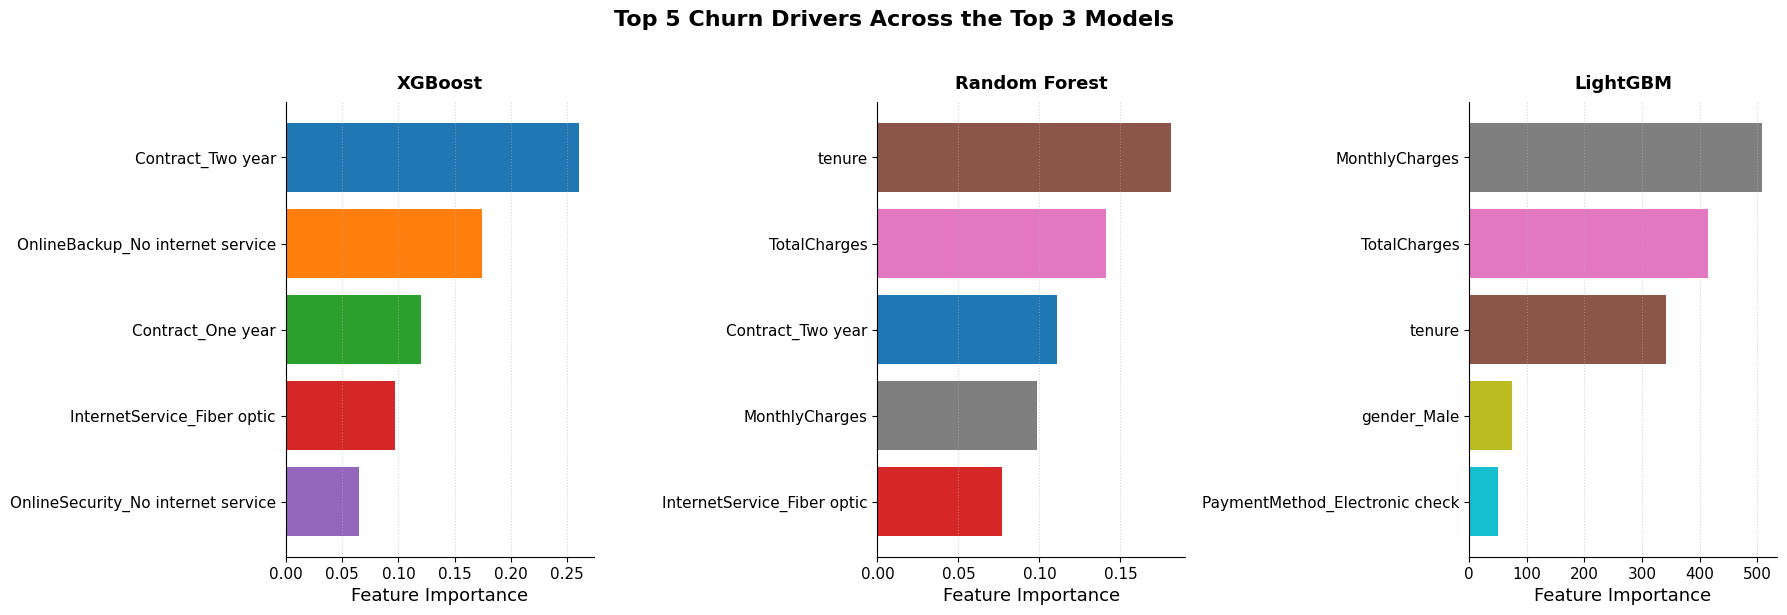

In [81]:

# 1. EXTRACT THE TUNED MODELS

models = {
    "XGBoost": best_xgb,
    "Random Forest": best_rf,
    "LightGBM": best_lgb
}

# 2. GET FEATURE NAMES
feature_names = X_train.columns

# 3. EXTRACT TOP 5 FEATURES FROM EACH MODEL

feature_importance_list = []

for model_name, model in models.items():

    # Extract classifier if model is inside a pipeline
    if hasattr(model, "named_steps"):
        model = model.named_steps["classifier"]

    # Extract feature importance
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    # Keep only the top 5
    importance_df = (
        importance_df.sort_values( by="Importance",
            ascending=False).head(5))
    
    importance_df["Model"] = model_name
    feature_importance_list.append(importance_df)


# 4. COMBINE ALL THREE MODELS

top_features = pd.concat(
    feature_importance_list,
    ignore_index=True
)

# 5. CREATE A CONSISTENT COLOR FOR EACH FEATURE

# Get every unique feature appearing in the top 5
all_top_features = top_features["Feature"].unique()

# Generate a unique color for each feature
feature_palette = dict(
    zip(all_top_features,
        sns.color_palette("tab10",
            n_colors=len(all_top_features))
    )
)


# 6. CREATE THE THREE-PANEL PLOT
fig, axes = plt.subplots(nrows=1, ncols=3,
    figsize=(18, 6))

for ax, model_name in zip(axes, models.keys()):

    # Select current model
    model_data = (
        top_features[
            top_features["Model"] == model_name
        ]
        .sort_values(
            by="Importance",
            ascending=True)
    )

    # Assign colors according to feature name
    bar_colors = [feature_palette[feature]
        for feature in model_data["Feature"]
    ]

    # Plot
    ax.barh(model_data["Feature"],
        model_data["Importance"],
        color=bar_colors
    )

    # Title
    ax.set_title(model_name, fontsize=13,
        fontweight="bold", pad=10)

    # Axis labels
    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("")

    # Grid
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# 7. OVERALL TITLE

plt.suptitle(
    "Top 5 Churn Drivers Across the Top 3 Models",
    fontsize=16, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()


The figure above compares the five most influential features identified by the three best-performing models: **Logistic Regression**, **LightGBM**, and **Random Forest**. Although each model quantifies feature importance differently, comparing their rankings provides valuable insight into the variables most strongly associated with customer churn.

#### Logistic Regression

Logistic Regression measures feature importance using the magnitude of its learned coefficients, which indicate the strength and direction of the relationship between each feature and the predicted probability of churn.

Within this model, **tenure** emerged as the strongest predictor, followed by **MonthlyCharges**. This suggests that customer longevity and monthly billing costs have the greatest influence on churn risk under a linear decision boundary.

Logistic Regression also identified **Contract_Two year** and **PhoneService** among its most influential features. The prominence of **Contract_Two year** indicates that customers on long-term contracts are substantially less likely to churn, highlighting contract duration as an important business factor associated with customer retention.


#### LightGBM

LightGBM measures feature importance according to the frequency with which each feature is selected for splitting across all decision trees.

The model identified **MonthlyCharges** and **TotalCharges** as its most influential variables, indicating that billing-related features frequently provide effective decision boundaries for separating churners from retained customers.

LightGBM was also the only model to include a demographic variable within its top five features. However, its relatively low importance compared with the leading variables suggests that demographic information contributes additional refinement rather than serving as a primary driver of churn predictions.


#### Random Forest

Random Forest measures feature importance using the average reduction in node impurity contributed by each feature across the ensemble of trees.

Within this model, **TotalCharges**, **tenure**, and **MonthlyCharges** received very similar importance scores, indicating that all three variables play significant roles in the classification process.

Random Forest ranked **TotalCharges** as the most important feature. It is worth noting that impurity-based feature importance can favour continuous variables with many unique values, meaning this result should be interpreted alongside the findings from the other models rather than in isolation.

Both Random Forest and LightGBM also identified **PaymentMethod_Electronic check** as one of the most influential categorical variables. This consistent ranking suggests that payment method is an important characteristic associated with customer churn, although the underlying reasons would require further business investigation.



---

### Conclusions and Recommendations

Despite their fundamentally different learning algorithms, all three models consistently ranked **tenure**, **MonthlyCharges**, and **TotalCharges** among their most influential features. This strong agreement increases confidence that customer tenure and billing characteristics are the primary factors associated with churn within this dataset.

Several secondary features also appeared consistently across multiple models. Long-term contracts (**Contract_Two year**) were associated with lower churn risk, while **PaymentMethod_Electronic check** emerged as an important predictor in the tree-based models. Although these variables contribute less than the primary billing and tenure features, they may provide valuable opportunities for targeted retention strategies.

These findings are consistent with the exploratory data analysis, which showed that customers with longer tenure generally exhibited lower churn rates.

### Business Implications

The feature importance analysis suggests that customer churn is primarily associated with **customer tenure** and **billing characteristics**. Customers who are relatively new and incur higher monthly charges appear to represent the highest-risk segment for churn.

The consistent importance of **Contract_Two year** suggests that encouraging customers to adopt longer-term contracts may improve retention, while the prominence of **PaymentMethod_Electronic check** indicates that payment method warrants further investigation as a potential indicator of elevated churn risk.

Overall, this suggests that the company should focus interventions on customers early in their lifecycle and those exhibiting higher monthly service costs.


### Save the model using joblib

In [ ]:
pip install joblib

In [ ]:
import joblib

# Save the entire dictionary to one file
joblib.dump(models, 'all_models.joblib')




`Author: CHIGOZIE OKONKWO`

`Electrical Engineer | Data Science | Teleco Customer Churn`    
* [Github](github.com/GotZie)
* [LinkedIn](linkedin.com/in/chigozie-okonkwo)>




<!-- `Author: CHIGOZIE OKONKWO`

`Electrical Engineer | Data Science | Teleco Customer Churn`    
* [Github](github.com/GotZie)
* [LinkedIn](linkedin.com/in/chigozie-okonkwo)>